<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS04/JS04-TugasLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Tugas Lab: Regresi**


---

# **Langkah 1: Persiapan Data**

> *Download dan letakkan file data `/content/insurance.csv` (Medical Cost Personal Dataset) pada direktori yang sama. Dataset ini berisi 1338 baris data biaya asuransi kesehatan personal di Amerika Serikat, dengan variabel:*
> - `age` — usia tertanggung (tahun)
> - `sex` — jenis kelamin
> - `bmi` — Body Mass Index
> - `children` — jumlah tanggungan
> - `smoker` — status merokok
> - `region` — wilayah tempat tinggal
> - `charges` — **biaya medis personal (variabel target/dependen)**
>
> Variabel bebas (fitur) yang digunakan: `age`, `sex`, `bmi`, `children`, `smoker`, `region`.

# **Langkah 2: Import Library**

In [43]:
# import package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

> *Import library NumPy dan Pandas yang digunakan untuk manipulasi data.*

# **Langkah 3: Baca Data**

In [44]:
# baca data dari file CSV
dataset = pd.read_csv('/content/insurance.csv')
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


> *Baca data dari file CSV dengan menggunakan Pandas.*

# **Langkah 4: Pemahaman Terhadap Data**

In [45]:
# melihat beberapa data awal
dataset.head()

# mengecek ukuran data
dataset.shape

# informasi tentang data
dataset.info()

# deskripsi data
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


> *Tampilkan beberapa data awal, ukuran data, informasi data, dan deskripsi statistik data untuk memahami karakteristik data.*

In [46]:
# mengecek missing value
dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# **Langkah 5: Visualisasi Data**

In [47]:
# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

> *Import library Matplotlib dan Seaborn untuk visualisasi data.*

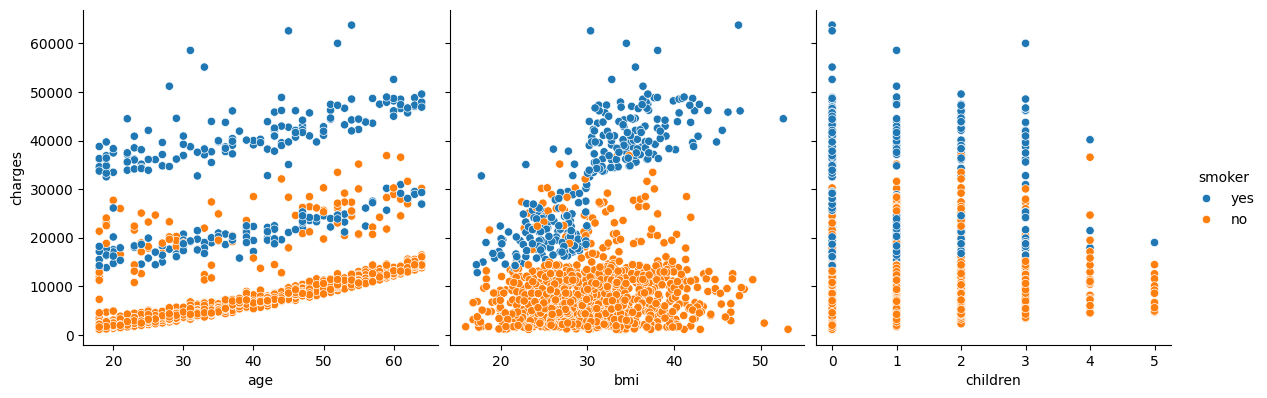

In [48]:
# visualisasi data dengan pairplot
sns.pairplot(dataset, x_vars=['age', 'bmi', 'children'],
             y_vars='charges', height=4, aspect=1, kind='scatter', hue='smoker')
plt.show()

> *Gunakan pairplot untuk menampilkan hubungan antara variabel bebas dan variabel target dalam bentuk scatter plot. Terlihat bahwa status `smoker` sangat memengaruhi pola sebaran `charges` terhadap `age` dan `bmi`.*

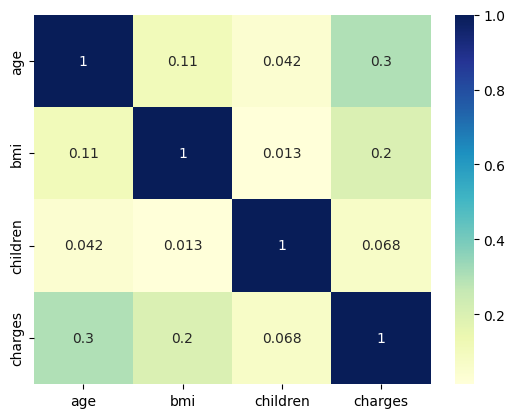

In [49]:
# visualisasi korelasi dengan heatmap
# Drop kolom non-numerik sebelum menghitung korelasi
numeric_data = dataset.drop(columns=['sex', 'smoker', 'region'], errors='ignore')
sns.heatmap(numeric_data.corr(), cmap="YlGnBu", annot=True)
plt.show()

> *Gunakan heatmap untuk menampilkan matriks korelasi antara variabel-variabel dalam dataset. Semakin tinggi nilainya, semakin tinggi korelasinya.*

# **Langkah 6: Encoding Variabel Kategorikal**

> *Variabel `sex`, `smoker`, dan `region` bertipe kategorikal sehingga perlu diubah menjadi variabel numerik (one-hot encoding) agar dapat diproses oleh model regresi.*

In [50]:
# encoding variabel kategorikal
dataset_encoded = pd.get_dummies(dataset, columns=['sex', 'smoker', 'region'], drop_first=True)
dataset_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# **Langkah 7: Membuat Variabel Bebas (X) dan Variabel Target (y)**

In [51]:
# Membuat variabel bebas X dan y, mengambil seluruh fitur hasil encoding
X = dataset_encoded.drop('charges', axis=1)
y = dataset_encoded['charges']

print("Fitur yang digunakan (X):", list(X.columns))

Fitur yang digunakan (X): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


> *Pisahkan variabel bebas (X) dan variabel target (y).*

# **Langkah 8: Split Data Latih dan Data Uji**

In [52]:
# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Jumlah data latih: 936
Jumlah data uji  : 402


> *Bagi data menjadi data latih (70%) dan data uji (30%) menggunakan `train_test_split`.*

# **Langkah 9: Feature Scaling**

> *Menggunakan `StandardScaler` untuk melakukan penskalaan fitur X dan target y. Ini diperlukan karena SVR sangat sensitif terhadap skala data.*

In [53]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# **Langkah 10: Multiple Linear Regression**

> *Buat model Multiple Linear Regression menggunakan Scikit-Learn, lalu latih pada data latih (fitur yang sudah di-scaling).*

In [54]:
# Training model Multiple Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Prediksi pada data uji
y_pred_lr = lr_model.predict(X_test_scaled)

# **Langkah 11: Analisis Residual (Multiple Linear Regression)**

> *Lakukan prediksi nilai y dari data latih dan hitung residual (selisih antara nilai sebenarnya dan nilai prediksi).*

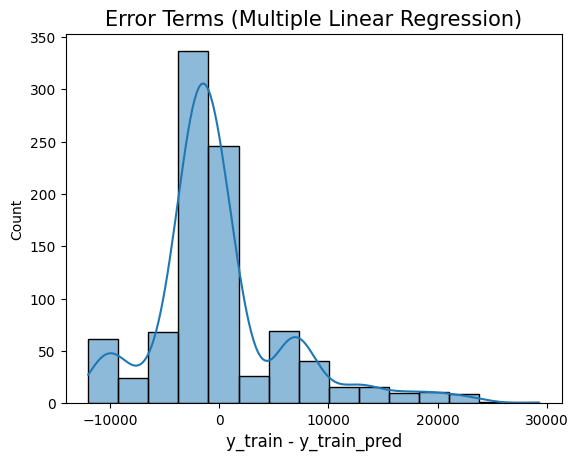

In [55]:
# Prediksi nilai y_train dari data yang telah dilatih
y_train_pred_lr = lr_model.predict(X_train_scaled)

# Menghitung residual
res = (y_train - y_train_pred_lr)

# Histogram residual
fig = plt.figure()
sns.histplot(res, bins=15, kde=True)
plt.title('Error Terms (Multiple Linear Regression)', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=12)
plt.show()

> *Visualisasikan residual dalam bentuk histogram untuk mengevaluasi distribusi error.*

# **Langkah 12: Evaluasi Model Multiple Linear Regression**

> *Hitung nilai R-squared, MSE, dan MAE untuk mengukur kinerja model pada data uji.*

In [56]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("=== Evaluasi Multiple Linear Regression ===")
print(f"R-squared : {r2_lr:.4f}")
print(f"MSE       : {mse_lr:.2f}")
print(f"MAE       : {mae_lr:.2f}")
print(f"RMSE      : {rmse_lr:.2f}")

=== Evaluasi Multiple Linear Regression ===
R-squared : 0.7772
MSE       : 32345536.75
MAE       : 3943.24
RMSE      : 5687.31


# **Langkah 13: Fitting Model SVR**

> *Lakukan pembuatan model SVR dengan kernel RBF (Radial Basis Function) dan melatihnya dengan data yang telah di-scaling, mengikuti pendekatan yang sama seperti pada Lab SVR sebelumnya.*

In [57]:
# Fitting SVR ke dataset (baseline, sebelum tuning)
from sklearn.svm import SVR

svr_base = SVR(kernel='rbf')
svr_base.fit(X_train_scaled, y_train_scaled)

SVR()

# **Langkah 14: Hyperparameter Tuning SVR**

> *Bereksperimen dengan hyperparameter tuning (`C`, `epsilon`, `gamma`) menggunakan `GridSearchCV` untuk mendapatkan kombinasi parameter SVR terbaik.*

In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['rbf'],
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled)

print("Parameter terbaik:", grid_search.best_params_)

svr_model = grid_search.best_estimator_

Parameter terbaik: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}


# **Langkah 15: Prediksi Hasil SVR**

> *Lakukan prediksi menggunakan model SVR yang telah dilatih (hasil prediksi perlu di-inverse transform karena target di-scaling).*

In [59]:
# Prediksi pada data uji
y_pred_svr_scaled = svr_model.predict(X_test_scaled)
y_pred_svr = sc_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

# **Langkah 16: Contoh Prediksi Individu**

> *Sebagai contoh penerapan, prediksi biaya medis untuk satu individu baru: usia 35 tahun, BMI 28, 2 anak, laki-laki, tidak merokok, wilayah northwest.*

In [60]:
# Buat data individu baru sesuai urutan kolom X
individu_baru = pd.DataFrame([{
    'age': 35, 'bmi': 28, 'children': 2,
    'sex_male': True, 'smoker_yes': False,
    'region_northwest': True, 'region_southeast': False, 'region_southwest': False
}])[X.columns]

# Penskalaan fitur untuk data yang akan diprediksi
individu_scaled = sc_X.transform(individu_baru)

# Prediksi menggunakan model SVR
prediksi_scaled = svr_model.predict(individu_scaled)
prediksi_charges = sc_y.inverse_transform(prediksi_scaled.reshape(-1, 1)).ravel()

print("Prediksi biaya medis untuk individu tersebut:", round(prediksi_charges[0], 2))

Prediksi biaya medis untuk individu tersebut: 6492.85


# **Langkah 17: Evaluasi Model SVR**

> *Hitung nilai MAE, MSE, RMSE, dan R-squared untuk mengukur kinerja model SVR pada data uji.*

In [61]:
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print("=== Evaluasi Support Vector Regression (SVR) ===")
print(f"MAE       : {mae_svr:.2f}")
print(f"MSE       : {mse_svr:.2f}")
print(f"RMSE      : {rmse_svr:.2f}")
print(f"R-squared : {r2_svr:.4f}")

=== Evaluasi Support Vector Regression (SVR) ===
MAE       : 2410.26
MSE       : 18026447.80
RMSE      : 4245.76
R-squared : 0.8758


In [62]:
# Tabel perbandingan kedua model
perbandingan = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'Support Vector Regression (SVR)'],
    'R-squared': [r2_lr, r2_svr],
    'MSE': [mse_lr, mse_svr],
    'MAE': [mae_lr, mae_svr],
    'RMSE': [rmse_lr, rmse_svr]
})
perbandingan

,Model,R-squared,MSE,MAE,RMSE
0,Multiple Linear Regression,0.777231,3.234554e+07,3943.237704,5687.313667
1,Support Vector Regression (SVR),0.875849,1.802645e+07,2410.260440,4245.756447


# **Langkah 18: Visualisasi Data Uji dan Hasil Prediksi**

> *Visualisasikan data uji dan hasil prediksi dalam bentuk scatter plot untuk kedua model.*

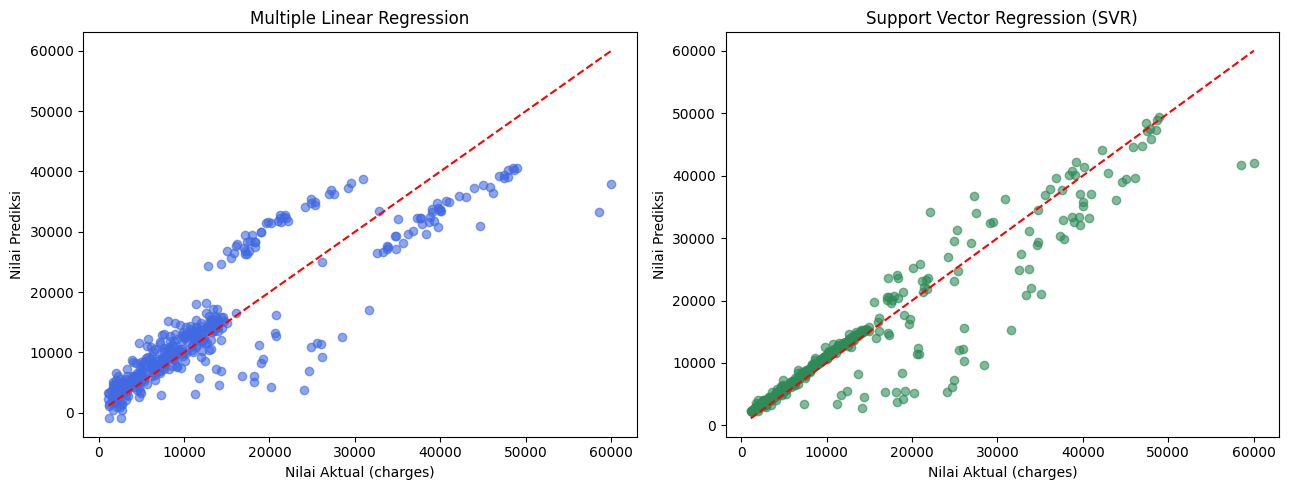

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Multiple Linear Regression')
axes[0].set_xlabel('Nilai Aktual (charges)')
axes[0].set_ylabel('Nilai Prediksi')

axes[1].scatter(y_test, y_pred_svr, alpha=0.6, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Support Vector Regression (SVR)')
axes[1].set_xlabel('Nilai Aktual (charges)')
axes[1].set_ylabel('Nilai Prediksi')

plt.tight_layout()
plt.show()

# **Analisis dan Kesimpulan**

> *Berdasarkan hasil evaluasi di atas:*
> - *Model **Multiple Linear Regression** (sesuai konsep pada modul: `y = α + β1x1 + β2x2 + ... + βnxn`) memberikan gambaran hubungan linear antara fitur `age`, `bmi`, `children`, `sex`, `smoker`, dan `region` terhadap `charges`.*
> - *Model **SVR** dengan kernel RBF (setelah hyperparameter tuning menggunakan `GridSearchCV`) dibandingkan untuk melihat apakah pendekatan non-linear dapat menangkap pola data dengan lebih baik.*
> - *Dari tabel perbandingan, model dengan nilai **R-squared lebih tinggi** serta **MSE, MAE, dan RMSE lebih rendah** dianggap sebagai model yang lebih baik dalam memprediksi biaya medis personal pada dataset ini.*
> - *Sejalan dengan hasil visualisasi EDA (pairplot & heatmap), fitur `smoker` teridentifikasi sebagai salah satu faktor paling berpengaruh terhadap besarnya biaya medis.*